In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "../data/corpus_baseline_onemonth.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


# RCT Historical Validation — Reproducibility Figures

This notebook reproduces **Figure 1**, **Table 2**, and **Table 3** from the paper.

- **Figure 1**: Pre-publication community sentiment — responders vs non-responders for 6 drugs
- **Table 2**: Data sources by drug (databases, window, post/user/report counts)
- **Table 3**: Per-drug response composition with Wilson 95% CIs and binomial test p-values

**Method.** For each drug, we extract all treatment-sentiment reports from
r/covidlonghaulers posts dated *before* the comparator paper was publicly
available (medRxiv preprint or journal online-first, whichever came first).
The analysis is restricted to data through end of 2022. All classified
reports come from a single self-sufficient SQLite database
(`historical_validation_2020-07_to_2022-12.db`). Each user contributes
exactly one data point per drug after deduplication: the **most recent report**
wins, with **signal_strength** as the tiebreaker for posts on the same date
(strong > moderate > weak > n/a). We then test whether the proportion of
responders (positive sentiment) differs from a 50% null using a two-sided
binomial test.


In [2]:

from pathlib import Path
from datetime import datetime, timezone
from scipy.stats import binomtest
from statsmodels.stats.proportion import proportion_confint as wilson

# ── Single self-sufficient analysis database ──
# This DB contains every classified treatment_report needed to reproduce the
# paper's figures and tables. Built by combining the master_gap pipeline run
# (2020-07-24 → 2022-12-31, all six target drugs) with the small number of
# additional classifications from earlier per-drug pipeline runs that were
# not present in master_gap. See README for provenance details.
DB_DIR = Path(DB_PATH).parent
COMBINED_DB = DB_DIR / "historical_validation_2020-07_to_2022-12.db"
combined_conn = sqlite3.connect(COMBINED_DB.as_posix())

# ── Signal-strength rank for tiebreaking ──
# Higher = stronger evidence. 'n/a' is treated as lowest because it means the
# classifier wasn't sure; we'd rather pick a confident weak/moderate report
# over an uncertain one when dates tie.
SIG_RANK = {"strong": 3, "moderate": 2, "weak": 1, "n/a": 0, None: 0, "": 0}

def fetch_drug_reports(drug, cutoff_ts):
    '''Pull all reports for a canonical drug from the combined DB,
    filtered to post_date <= cutoff_ts.'''
    return combined_conn.execute('''
        SELECT tr.user_id,
               lower(t.canonical_name) AS drug,
               tr.sentiment,
               tr.signal_strength      AS sig,
               p.post_date,
               tr.post_id
        FROM treatment_reports tr
        JOIN treatment t ON tr.drug_id = t.id
        JOIN posts     p ON tr.post_id = p.post_id
        WHERE lower(t.canonical_name) = ?
          AND p.post_date IS NOT NULL
          AND p.post_date <= ?
    ''', (drug, cutoff_ts)).fetchall()

def dedup_recent_then_strength(rows):
    '''Per (user, drug): keep the most recent report; for same-date ties,
    keep the strongest signal.'''
    by_user = {}
    for row in rows:
        uid, drug, sent, sig, d, _pid = row
        date = d or 0
        sig_r = SIG_RANK.get(sig, 0)
        key = (uid, drug)
        if key not in by_user:
            by_user[key] = (date, sig_r, sent)
            continue
        cur_date, cur_sig, _ = by_user[key]
        if date > cur_date or (date == cur_date and sig_r > cur_sig):
            by_user[key] = (date, sig_r, sent)
    return [(uid_drug[0], uid_drug[1], v[2]) for uid_drug, v in by_user.items()]

def epoch_eod(date_str):
    return int(datetime.strptime(date_str, '%Y-%m-%d').replace(
        tzinfo=timezone.utc, hour=23, minute=59, second=59).timestamp())

# Pre-publication cutoffs are the day BEFORE the earliest public release.
# Effective cutoff is min(pub_cutoff, end-of-2022) per the analysis design.
END_2022 = '2022-12-31'

DRUG_CUTOFFS = {
    # drug -> (cutoff_yyyy_mm_dd, paper_short, source_and_date)
    'famotidine':  ('2021-06-06', 'Glynne et al. 2021',          'medRxiv 2021-06-07'),
    'loratadine':  ('2021-06-06', 'Glynne et al. 2021',          'medRxiv 2021-06-07'),
    'prednisone':  ('2021-10-25', 'Utrero-Rico et al. 2021',     'Biomedicines 2021-10-26'),
    'naltrexone':  ('2022-07-02', 'O′Kelly et al. 2022',         'BBI Health 2022-07-03'),
    'paxlovid':    ('2024-06-06', 'Geng et al. 2024 (STOP-PASC)', 'JAMA Intern Med 2024-06-07'),
    'colchicine':  ('2025-11-30', 'Bassi et al. 2025',           'JAMA Intern Med 2025-12-01'),
}


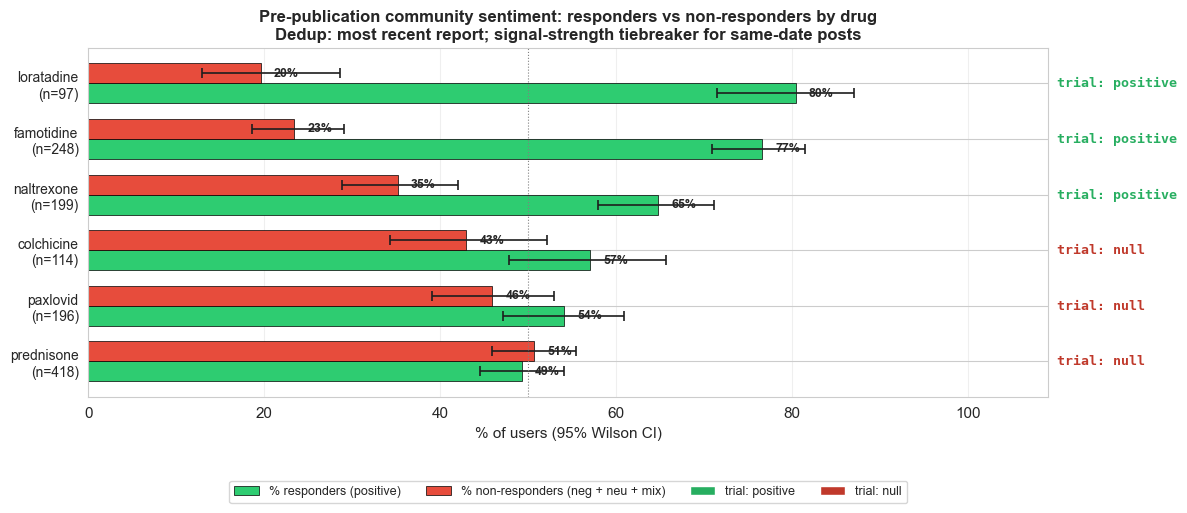

In [3]:

def _sentiment_breakdown(drug_label, sentiments, trial_dir, paper_short, source_date):
    n = len(sentiments)
    pos = sum(1 for s in sentiments if s == 'positive')
    neg = sum(1 for s in sentiments if s == 'negative')
    neu = sum(1 for s in sentiments if s == 'neutral')
    mix = sum(1 for s in sentiments if s == 'mixed')
    nonr = neg + neu + mix
    pos_lo, pos_hi   = wilson(pos,  n, alpha=0.05, method='wilson') if n else (0, 0)
    nonr_lo, nonr_hi = wilson(nonr, n, alpha=0.05, method='wilson') if n else (0, 0)
    pval = binomtest(pos, n, 0.5, alternative='two-sided').pvalue if n else 1.0
    return {
        'drug': drug_label, 'n': n, 'trial_dir': trial_dir,
        'paper': paper_short, 'source_date': source_date,
        'pos': pos, 'neg': neg, 'neu': neu, 'mix': mix, 'nonr': nonr,
        'pos_pct': pos/n*100 if n else 0,
        'pos_lo': pos_lo*100, 'pos_hi': pos_hi*100,
        'nonr_pct': nonr/n*100 if n else 0,
        'nonr_lo': nonr_lo*100, 'nonr_hi': nonr_hi*100,
        'pval': pval,
    }

# Trial directions for each drug
TRIAL_DIRS = {
    'famotidine': '+',
    'loratadine': '+',
    'naltrexone': '+',
    'prednisone': '0',
    'paxlovid':   '0',
    'colchicine': '0',
}

resp_rows = []
for drug, (pub_cutoff, paper_short, source_date) in DRUG_CUTOFFS.items():
    effective_cutoff = min(pub_cutoff, END_2022)
    cutoff_ts = epoch_eod(effective_cutoff)
    rows = fetch_drug_reports(drug, cutoff_ts)
    dedup = dedup_recent_then_strength(rows)
    sentiments = [s for _u, _d, s in dedup]
    resp_rows.append(_sentiment_breakdown(drug, sentiments, TRIAL_DIRS[drug], paper_short, source_date))

resp_df = (pd.DataFrame(resp_rows)
           .sort_values('pos_pct', ascending=False)
           .reset_index(drop=True))

# ── Figure 1: Paired horizontal bars with trial-direction tags ──
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 5.5))
y = np.arange(len(resp_df))[::-1]
bar_h = 0.36

# Responder bars (green)
ax.barh(y - bar_h/2, resp_df['pos_pct'], height=bar_h,
        color='#2ecc71', edgecolor='black', linewidth=0.5,
        label='% responders (positive)')
ax.errorbar(resp_df['pos_pct'], y - bar_h/2,
            xerr=[resp_df['pos_pct'] - resp_df['pos_lo'],
                  resp_df['pos_hi'] - resp_df['pos_pct']],
            fmt='none', ecolor='#1e1e1e', elinewidth=1.2, capsize=3.5, capthick=1.2)

# Non-responder bars (red)
ax.barh(y + bar_h/2, resp_df['nonr_pct'], height=bar_h,
        color='#e74c3c', edgecolor='black', linewidth=0.5,
        label='% non-responders (neg + neu + mix)')
ax.errorbar(resp_df['nonr_pct'], y + bar_h/2,
            xerr=[resp_df['nonr_pct'] - resp_df['nonr_lo'],
                  resp_df['nonr_hi'] - resp_df['nonr_pct']],
            fmt='none', ecolor='#1e1e1e', elinewidth=1.2, capsize=3.5, capthick=1.2)

# Value labels on bars
for i, r in resp_df.iterrows():
    ax.text(r['pos_pct'] + 1.5, y[i] - bar_h/2, f"{r['pos_pct']:.0f}%",
            va='center', ha='left', fontsize=9, fontweight='bold')
    ax.text(r['nonr_pct'] + 1.5, y[i] + bar_h/2, f"{r['nonr_pct']:.0f}%",
            va='center', ha='left', fontsize=9, fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels([f"{r['drug']}\n(n={r['n']})" for _, r in resp_df.iterrows()], fontsize=10)
ax.set_xlim(0, max(resp_df['pos_hi'].max(), resp_df['nonr_hi'].max()) + 22)
ax.set_xlabel('% of users (95% Wilson CI)', fontsize=11)
ax.axvline(50, color='gray', ls=':', lw=0.8)
ax.set_title('Pre-publication community sentiment: responders vs non-responders by drug\n'
             'Dedup: most recent report; signal-strength tiebreaker for same-date posts',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Trial-direction tags in the right margin
TAG_STYLE = {
    '+': ('trial: positive', '#27ae60'),
    '0': ('trial: null',     '#c0392b'),
}
for i, r in resp_df.iterrows():
    label, color = TAG_STYLE.get(r['trial_dir'], (f"trial: {r['trial_dir']}", '#7f8c8d'))
    ax.text(1.01, y[i], label, transform=ax.get_yaxis_transform(),
            va='center', ha='left', fontsize=9.5, family='monospace',
            color=color, fontweight='bold')

legend_elems = [
    Patch(facecolor='#2ecc71', edgecolor='black', linewidth=0.5,
          label='% responders (positive)'),
    Patch(facecolor='#e74c3c', edgecolor='black', linewidth=0.5,
          label='% non-responders (neg + neu + mix)'),
    Patch(facecolor='#27ae60', label='trial: positive'),
    Patch(facecolor='#c0392b', label='trial: null'),
]
ax.legend(handles=legend_elems, loc='lower center', bbox_to_anchor=(0.5, -0.32),
          ncol=4, fontsize=9, frameon=True)
plt.tight_layout()
plt.savefig('figure1.png', dpi=150, bbox_inches='tight')
plt.show()


## Data sources and methodology

**Definitions:**
- **Responder**: user's selected report has `positive` sentiment.
- **Non-responder**: user's selected report has any other sentiment (negative, neutral, or mixed).

**Per-(user, drug) deduplication rule:**
- Most recent post wins (post_date descending).
- For posts on the same date, the report with stronger `signal_strength`
  wins (strong > moderate > weak > n/a).

**Window cap:** all data is restricted to posts from the corpus inception
(2020-07-24) through end of 2022 (2022-12-31). For famotidine, loratadine,
prednisone, and naltrexone the comparator publication date is the binding
cutoff. For paxlovid (publication June 2024) and colchicine (December 2025),
the end-2022 cap is the binding cutoff.

In [4]:

# ── Table 2: Data sources by drug ──
# Pulls user/report counts directly from the merged data so the table
# auto-updates if the underlying DBs change.
src_rows = []
for drug, (pub_cutoff, paper_short, source_date) in DRUG_CUTOFFS.items():
    effective_cutoff = min(pub_cutoff, END_2022)
    cutoff_ts = epoch_eod(effective_cutoff)
    rows = fetch_drug_reports(drug, cutoff_ts)
    n_reports = len(rows)
    n_users = len({(uid, dr) for uid, dr, _s, _sg, _d, _p in rows})
    src_rows.append({
        'drug': drug,
        'databases': 'historical_validation_2020-07_to_2022-12.db',
        'window_start': '2020-07-24',
        'window_end': effective_cutoff,
        'unique_users': n_users,
        'treatment_reports': n_reports,
        'comparator': f"{paper_short} ({source_date})",
    })
src_df = pd.DataFrame(src_rows)

src_html = "<table style='border-collapse:collapse; width:100%; font-size:0.85em; margin:12px 0;'>"
src_html += ("<tr style='background:#34495e; color:white;'>"
             "<th style='padding:6px 10px;'>Drug</th>"
             "<th style='padding:6px 10px;'>Window</th>"
             "<th style='padding:6px 10px;'>Unique users</th>"
             "<th style='padding:6px 10px;'>Treatment reports</th>"
             "<th style='padding:6px 10px;'>Comparator paper</th></tr>")
for i, (_, r) in enumerate(src_df.iterrows()):
    bg = '#fff' if i % 2 == 0 else '#f8f9fa'
    src_html += (f"<tr style='background:{bg};'>"
                 f"<td style='padding:6px 10px; font-weight:bold;'>{r['drug']}</td>"
                 f"<td style='padding:6px 10px;'>{r['window_start']} → {r['window_end']}</td>"
                 f"<td style='padding:6px 10px; text-align:center;'>{r['unique_users']}</td>"
                 f"<td style='padding:6px 10px; text-align:center;'>{r['treatment_reports']}</td>"
                 f"<td style='padding:6px 10px; font-size:0.85em;'>{r['comparator']}</td></tr>")
src_html += "</table>"
src_html += ("<p style='font-size:0.85em; color:#777; margin-top:4px;'>"
             "All counts are drawn from a single SQLite database "
             "(<code>historical_validation_2020-07_to_2022-12.db</code>) constructed for this paper. "
             "Unique users: distinct users with at least one classified report for the drug. "
             "Treatment reports: total post-level reports before per-user dedup. "
             "Window cap at end of 2022 applies to paxlovid and colchicine; for the other four drugs the "
             "comparator publication date is the binding cutoff.</p>")

display(HTML("<h3>Table 2 &mdash; Data sources by drug</h3>" + src_html))


Drug,Window,Unique users,Treatment reports,Comparator paper
famotidine,2020-07-24 → 2021-06-06,248,733,Glynne et al. 2021 (medRxiv 2021-06-07)
loratadine,2020-07-24 → 2021-06-06,97,205,Glynne et al. 2021 (medRxiv 2021-06-07)
prednisone,2020-07-24 → 2021-10-25,418,919,Utrero-Rico et al. 2021 (Biomedicines 2021-10-26)
naltrexone,2020-07-24 → 2022-07-02,199,680,O′Kelly et al. 2022 (BBI Health 2022-07-03)
paxlovid,2020-07-24 → 2022-12-31,196,488,Geng et al. 2024 (STOP-PASC) (JAMA Intern Med 2024-06-07)
colchicine,2020-07-24 → 2022-12-31,114,252,Bassi et al. 2025 (JAMA Intern Med 2025-12-01)


In [5]:

# ── Table 3: Response composition ──
table_df = resp_df[['drug', 'paper', 'source_date', 'n', 'pos', 'pos_pct',
                    'pos_lo', 'pos_hi', 'nonr', 'nonr_pct',
                    'nonr_lo', 'nonr_hi', 'pval']].copy()

def _fmt_pct(v): return f"{v:.1f}%"
def _fmt_ci(lo, hi): return f"[{lo:.1f}%, {hi:.1f}%]"
def _fmt_p(v):
    if v < 0.0001:  return "<0.0001"
    if v < 0.001:   return f"{v:.4f}"
    return f"{v:.3f}"

table_df['% responders']      = table_df['pos_pct'].apply(_fmt_pct)
table_df['responders 95% CI'] = [_fmt_ci(lo, hi) for lo, hi in zip(table_df['pos_lo'], table_df['pos_hi'])]
table_df['% non-resp']        = table_df['nonr_pct'].apply(_fmt_pct)
table_df['non-resp 95% CI']   = [_fmt_ci(lo, hi) for lo, hi in zip(table_df['nonr_lo'], table_df['nonr_hi'])]
table_df['p (vs 50%)']        = table_df['pval'].apply(_fmt_p)

display_table = table_df[['drug', 'paper', 'source_date', 'n',
                          '% responders', 'responders 95% CI',
                          'nonr', '% non-resp', 'non-resp 95% CI',
                          'p (vs 50%)']].rename(columns={
                              'paper':        'Comparator paper',
                              'source_date':  'Source / first public date',
                              'nonr':         '-/0/~',
                          })

display(HTML("<h3>Table 3 &mdash; Per-drug response composition (pre-publication data only)</h3>"
             "<p style='font-size:0.9em; color:#555;'>Each row: one (user, drug) per cell after the "
             "<i>most recent + signal-strength tiebreaker</i> dedup rule. "
             "Responders = positive sentiment; non-responders = negative + neutral + mixed. "
             "<i>p</i> values from a two-sided binomial test against the 50% null "
             "(H&#8320;: P(responder) = 0.5). The 'Source / first public date' column gives the "
             "earliest publicly available release of the comparator paper "
             "(medRxiv preprint where available, otherwise journal online-first).</p>"
             + display_table.to_html(index=False)))


drug,Comparator paper,Source / first public date,n,% responders,responders 95% CI,-/0/~,% non-resp,non-resp 95% CI,p (vs 50%)
loratadine,Glynne et al. 2021,medRxiv 2021-06-07,97,80.4%,"[71.4%, 87.1%]",19,19.6%,"[12.9%, 28.6%]",<0.0001
famotidine,Glynne et al. 2021,medRxiv 2021-06-07,248,76.6%,"[71.0%, 81.5%]",58,23.4%,"[18.5%, 29.0%]",<0.0001
naltrexone,O′Kelly et al. 2022,BBI Health 2022-07-03,199,64.8%,"[58.0%, 71.1%]",70,35.2%,"[28.9%, 42.0%]",<0.0001
colchicine,Bassi et al. 2025,JAMA Intern Med 2025-12-01,114,57.0%,"[47.8%, 65.7%]",49,43.0%,"[34.3%, 52.2%]",0.160
paxlovid,Geng et al. 2024 (STOP-PASC),JAMA Intern Med 2024-06-07,196,54.1%,"[47.1%, 60.9%]",90,45.9%,"[39.1%, 52.9%]",0.284
prednisone,Utrero-Rico et al. 2021,Biomedicines 2021-10-26,418,49.3%,"[44.5%, 54.1%]",212,50.7%,"[45.9%, 55.5%]",0.807
